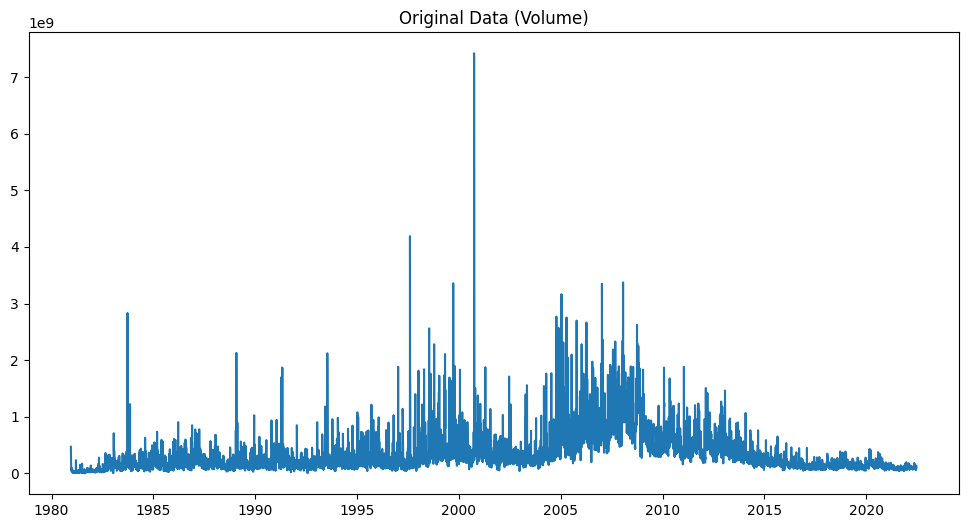

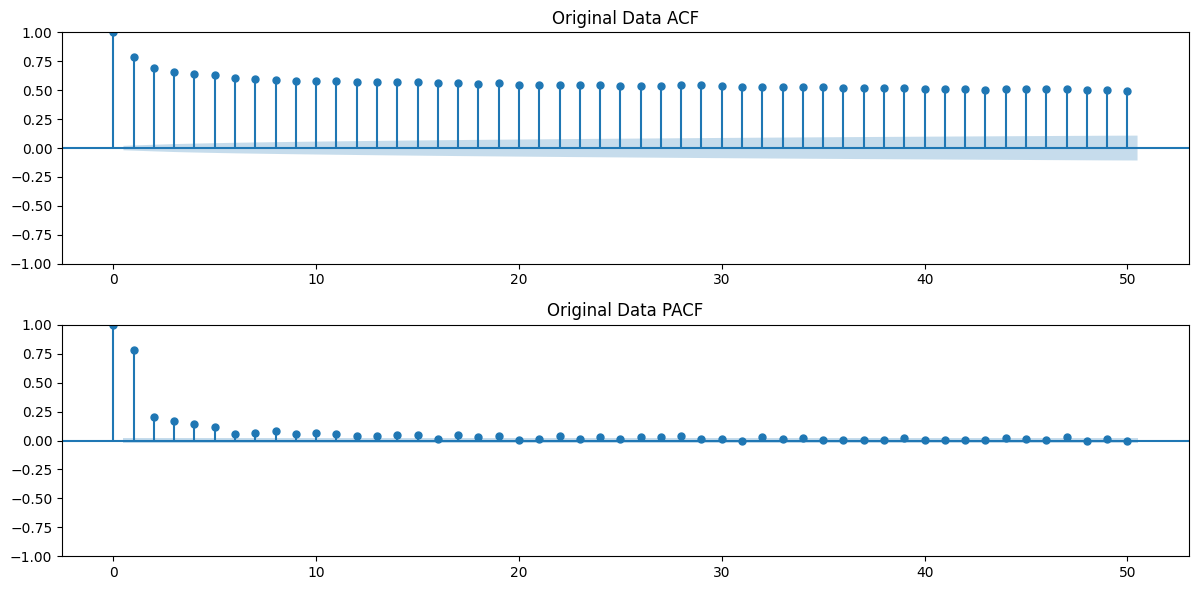

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


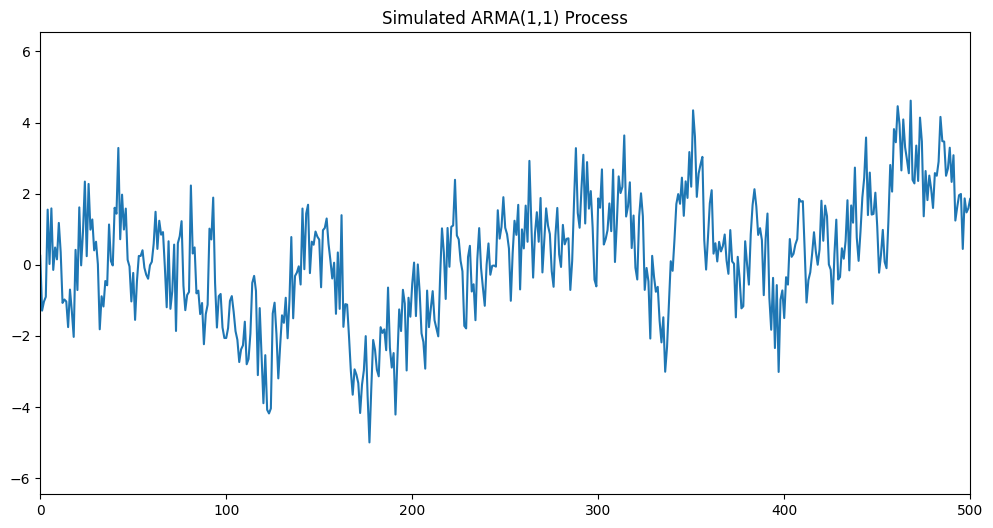

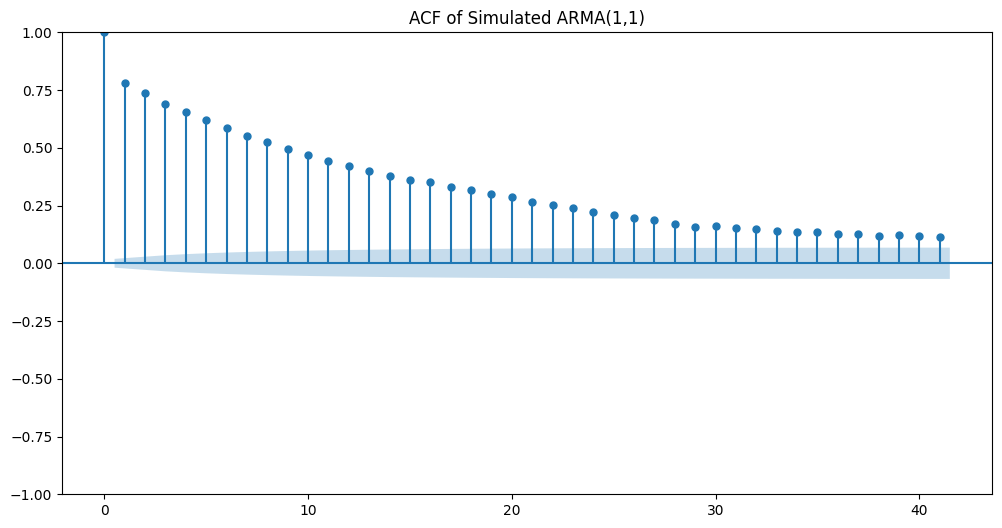

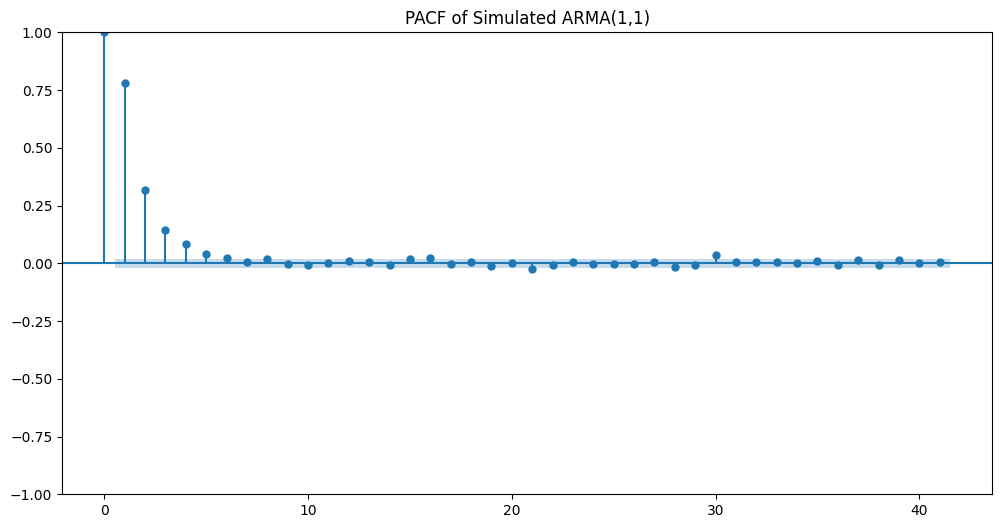

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


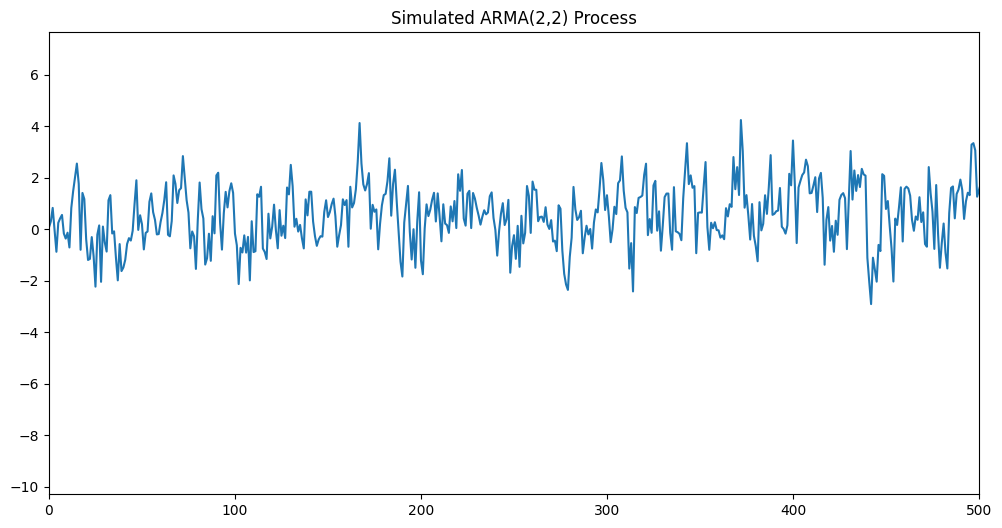

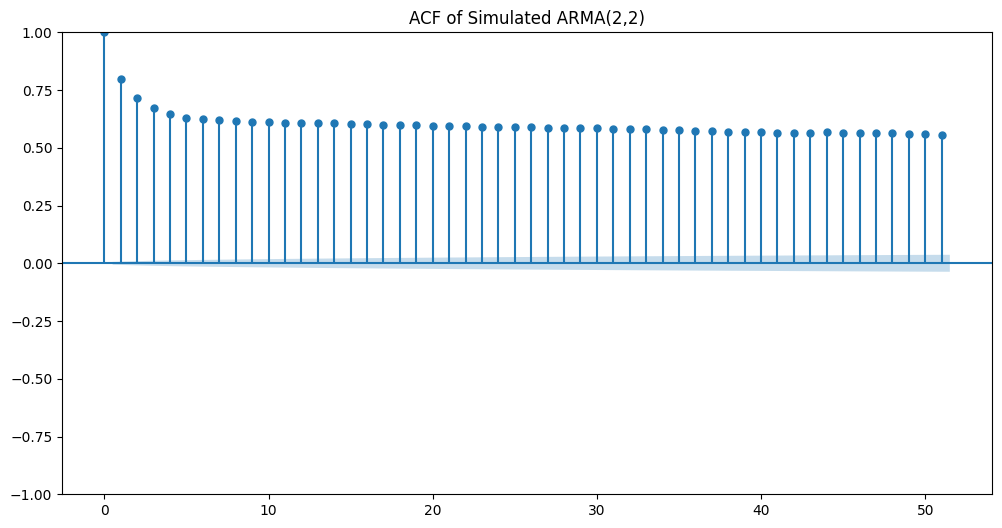

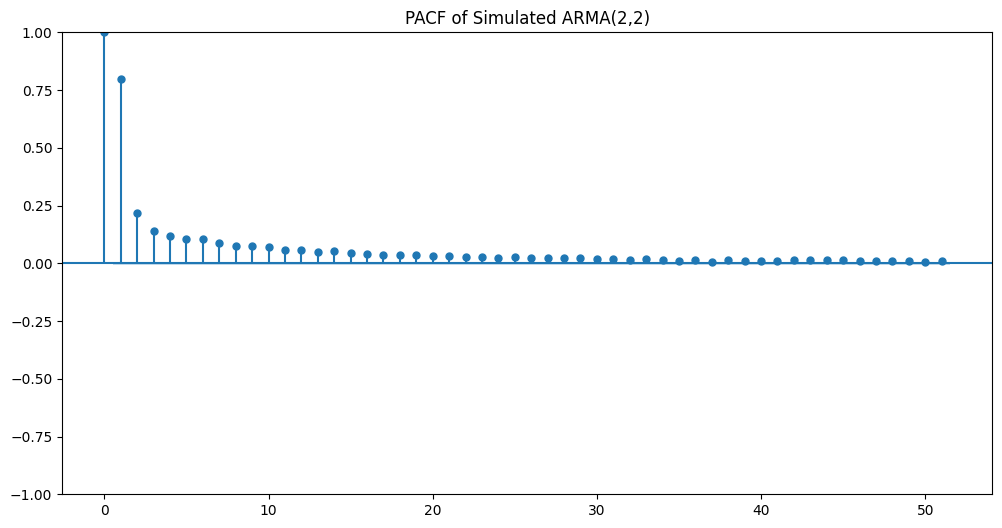

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


data = pd.read_csv('/content/drive/MyDrive/COLAB PROJECTS/Time Series/apple.csv')

data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

N = len(data)

plt.rcParams['figure.figsize'] = [12, 6]

X = data['Volume']

# Original Data Plot
plt.plot(X)
plt.title('Original Data (Volume)')
plt.show()

# ACF & PACF
plt.subplot(2, 1, 1)
plot_acf(X, lags=50, ax=plt.gca())
plt.title('Original Data ACF')

plt.subplot(2, 1, 2)
plot_pacf(X, lags=50, ax=plt.gca())
plt.title('Original Data PACF')

plt.tight_layout()
plt.show()
# ARMA(1,1)

arma11_model = ARIMA(X, order=(1, 0, 1)).fit()

phi1_arma11 = arma11_model.params['ar.L1']
theta1_arma11 = arma11_model.params['ma.L1']

ar1 = np.array([1, -phi1_arma11])
ma1 = np.array([1, theta1_arma11])

ARMA_1 = ArmaProcess(ar1, ma1).generate_sample(nsample=N)

plt.plot(ARMA_1)
plt.title('Simulated ARMA(1,1) Process')
plt.xlim([0, 500])
plt.show()

plot_acf(ARMA_1)
plt.title('ACF of Simulated ARMA(1,1)')
plt.show()

plot_pacf(ARMA_1)
plt.title('PACF of Simulated ARMA(1,1)')
plt.show()

# ARMA(2,2)
arma22_model = ARIMA(X, order=(2, 0, 2)).fit()

phi1_arma22 = arma22_model.params['ar.L1']
phi2_arma22 = arma22_model.params['ar.L2']

theta1_arma22 = arma22_model.params['ma.L1']
theta2_arma22 = arma22_model.params['ma.L2']

ar2 = np.array([1, -phi1_arma22, -phi2_arma22])
ma2 = np.array([1, theta1_arma22, theta2_arma22])

ARMA_2 = ArmaProcess(ar2, ma2).generate_sample(nsample=N*10)

plt.plot(ARMA_2)
plt.title('Simulated ARMA(2,2) Process')
plt.xlim([0, 500])
plt.show()

plot_acf(ARMA_2)
plt.title('ACF of Simulated ARMA(2,2)')
plt.show()

plot_pacf(ARMA_2)
plt.title('PACF of Simulated ARMA(2,2)')
plt.show()